# 4교시 · QLoRA 학습 (핵심)

> **VLM 경량화 2일 과정 · Day 1 (4교시) · 실습**
> 실습 환경: **Google Colab (T4 GPU)** · 모델: **Qwen/Qwen3-VL-4B-Instruct** · 데이터: **HuggingFaceM4/ChartQA**

---

## 이 교시의 목표
- **4bit 동결 base + LoRA 어댑터** 구조(QLoRA)를 구성한다(`prepare_model_for_kbit_training`).
- **비전 타워는 동결**, LLM 선형층에만 LoRA를 타깃팅한다.
- **`paged_adamw_8bit`** + **grad checkpointing** + fp16으로 **T4 메모리 안에서** 파인튜닝한다.
- 학습곡선을 읽고, *full-precision LoRA* 대비 QLoRA의 메모리 절감을 수치로 본다.

> 이번 교시는 2·3교시 산출물을 이어받습니다. 새 런타임이면 아래 **준비 셀**(설치·모델·데이터)을 먼저 실행하세요.


## 0. 공통 헤더 — Google Drive(VLM_FT_2) 마운트 + HF_TOKEN 로드

> 📌 **모든 Day 1 노트북은 이 셀을 먼저 실행합니다.** Google Drive의 작업 폴더 **`VLM_FT_2`** 를 마운트하고, `.env`의 **HF_TOKEN**을 불러옵니다.
> - `VLM_DIR` / `DATA_DIR` : 교시 간 공유 폴더(전처리 데이터·어댑터·결과가 여기 모입니다).
> - **HF_TOKEN**: `VLM_FT_2/.env` 에 `HF_TOKEN=hf_...` 한 줄을 넣어두면 자동 로드됩니다(다운로드 경고 방지·비공개 모델 접근). `login()`은 호출하지 않습니다(환경변수만으로 충분, 경고 방지).

In [1]:
# ════════════════════════════════════════════════════════════
#  공통 헤더 · Google Drive(VLM_FT_2) 마운트 + HF_TOKEN(.env) 로드
#  (모든 Day1 노트북 상단에서 동일하게 실행)
# ════════════════════════════════════════════════════════════
import os

# (1) Google Drive 마운트 → 작업 폴더 VLM_FT_2 (교시 간 데이터·어댑터·결과 공유)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    VLM_DIR = '/content/drive/MyDrive/VLM_FT_2'      # Drive 경로(권장)
except Exception:
    VLM_DIR = '/content/VLM_FT_2'                     # Colab 아니면 로컬 폴백
DATA_DIR = f'{VLM_DIR}/data'
os.makedirs(DATA_DIR, exist_ok=True)

# (2) .env 에서 HF_TOKEN 로드. login()은 부르지 않음(환경변수만으로 인증, 경고 없음).
try:
    from dotenv import load_dotenv
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'python-dotenv'])
    from dotenv import load_dotenv
ENV_PATH = f'{VLM_DIR}/.env'
if os.path.exists(ENV_PATH):
    load_dotenv(ENV_PATH)
    print('HF_TOKEN:', '로드됨' if os.environ.get('HF_TOKEN') else '없음')
else:
    print(f'.env 없음 — {ENV_PATH} 에 HF_TOKEN=hf_... 한 줄을 만들면 자동 로드됩니다(공개 데이터만 쓰면 없어도 됨)')
print('작업 폴더 VLM_DIR =', VLM_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HF_TOKEN: 로드됨
작업 폴더 VLM_DIR = /content/drive/MyDrive/VLM_FT_2


## 0. 준비 — 2·3교시 요약 재실행

(같은 런타임을 이어 쓰면 건너뛰어도 됩니다.) 설치 → 프로세서 → 4bit 모델 → 서브셋 → `collate_fn` 을 한 번에 복원합니다.

In [2]:
# 설치 (2교시와 동일)
!pip install -q -U "transformers>=4.57" "accelerate>=1.0" "bitsandbytes>=0.44" "datasets>=3.0" "peft>=0.13" "qwen-vl-utils>=0.0.8" "python-dotenv" "pillow<12"
import torch, transformers
print('transformers:', transformers.__version__)

transformers: 5.12.1


In [3]:
# 프로세서 + 4bit 모델 로드
# - processor: 이미지/텍스트를 모델 입력 형식으로 변환
# - model: Qwen3-VL 4B를 4bit로 불러와 메모리 사용량을 줄임
from transformers import (Qwen3VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig)

MODEL_ID = 'Qwen/Qwen3-VL-4B-Instruct'

# 이미지 입력 크기 제한
# - 너무 작은 이미지는 정보 손실 가능
# - 너무 큰 이미지는 VRAM 사용량 증가
MIN_PIXELS, MAX_PIXELS = 64 * 28 * 28, 256 * 28 * 28

# 프로세서 로드
# - min_pixels / max_pixels로 이미지 토큰 범위를 제어
processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)

# 라벨 마스킹을 위해 오른쪽 패딩 사용
# - 학습 시 정답 토큰 위치를 맞추기 쉬움
processor.tokenizer.padding_side = 'right'

# bitsandbytes 4bit 양자화 설정
# - nf4: 4bit 양자화 방식
# - double quant: 추가 압축으로 메모리 절감
# - compute_dtype: 연산 정밀도(fp16)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

# 4bit 모델 로드
# - device_map='auto': 사용 가능한 GPU/CPU에 자동 배치
# - dtype=torch.float16: 계산 정밀도 지정
# - attn_implementation='sdpa': 효율적인 attention 사용
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='auto',
    dtype=torch.float16,
    attn_implementation='sdpa',
)

print('4bit 모델 로드 완료')

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


4bit 모델 로드 완료


In [4]:
# ─────────────────────────────────────────────────────────────
# 서브셋 로드 + collate_fn 구성
# (Day1-3에서 사용한 패턴 재사용: 시스템 프롬프트 + 라벨 마스킹 학습)
# ─────────────────────────────────────────────────────────────
from datasets import load_dataset, load_from_disk

TRAIN_N = 3000  # 학습에 사용할 샘플 수

# Day1-3에서 저장해둔 동일 크기/시드의 데이터가 있으면 우선 재사용
# (없으면 원본 train split에서 동일 시드로 셔플 후 앞 TRAIN_N개 선택)
TRAIN_PATH = f'{DATA_DIR}/chartqa_train_{TRAIN_N}'
if os.path.isdir(TRAIN_PATH):
    train_set = load_from_disk(TRAIN_PATH)
    print('Day1-3 저장본 로드:', TRAIN_PATH)
else:
    train_set = (
        load_dataset('HuggingFaceM4/ChartQA', split='train')
        .shuffle(seed=42)
        .select(range(TRAIN_N))
    )
    print('저장본 없음 → 동일 시드 샘플링')

# ── 시스템 프롬프트 + 메시지/이미지 헬퍼 ─────────────────────
from PIL import Image
from qwen_vl_utils import process_vision_info  # 메시지 내부의 image 정보를 모델 입력 형식으로 정리

# 모델이 장황하게 답하지 않도록 "짧은 정답" 형식을 강제
SYSTEM = "당신은 차트를 읽고 질문에 답하는 도우미입니다. 설명 없이 한 단어 또는 숫자로만 짧게 답하세요."

def shrink(img, max_side=768):
    """
    이미지 전처리:
    1) 긴 변이 max_side보다 크면 비율 유지 축소
    2) 최종 색상 모드는 RGB로 통일
    """
    w, h = img.size
    s = max_side / max(w, h)
    if s < 1:  # 큰 이미지만 축소
        img = img.resize((int(w * s), int(h * s)), Image.LANCZOS)
    return img.convert("RGB")

def to_messages(image, question, answer=None):
    """
    단일 샘플을 Qwen 채팅 메시지 형식으로 변환.
    - answer가 있으면 학습용(assistant 정답 포함)
    - answer가 없으면 추론 프롬프트용(assistant 자리만 열어둠)
    """
    msgs = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM}]},
        {"role": "user",   "content": [
            {"type": "image", "image": image},
            {"type": "text",  "text": question}
        ]},
    ]
    if answer is not None:
        msgs.append({"role": "assistant", "content": [{"type": "text", "text": answer}]})
    return msgs

def collate_fn(batch):
    """
    DataLoader용 collate 함수.
    입력:  batch(list of dict) - 각 원소는 {image, query, label}
    출력:  model_inputs(dict) - input_ids/attention_mask/pixel_values/... + labels
    핵심:  labels에서 '프롬프트 구간'과 '패딩'을 -100으로 마스킹해
          정답 토큰에 대해서만 loss를 계산하도록 구성
    """
    # 1) 이미지 크기/모드 표준화
    imgs = [shrink(b["image"]) for b in batch]

    # 2) 메시지 2종 준비
    #    - full_msgs: 정답 포함(모델 실제 입력)
    #    - prompt_msgs: 정답 제외(라벨 마스킹 경계 계산용)
    full_msgs = [to_messages(im, b["query"], str(b["label"][0])) for im, b in zip(imgs, batch)]
    prompt_msgs = [to_messages(im, b["query"], None) for im, b in zip(imgs, batch)]

    # 3) 채팅 템플릿 문자열 변환
    #    - full_texts: assistant 정답까지 포함된 완성 텍스트
    #    - prompt_texts: assistant 생성 시작 직전까지만 포함
    full_texts = [
        processor.apply_chat_template(m, tokenize=False, add_generation_prompt=False)
        for m in full_msgs
    ]
    prompt_texts = [
        processor.apply_chat_template(m, tokenize=False, add_generation_prompt=True)
        for m in prompt_msgs
    ]

    # 4) 멀티모달 입력용 이미지 리스트 평탄화 (샘플당 1장)
    image_inputs = []
    for m in full_msgs:
        ii, _ = process_vision_info(m)
        image_inputs.extend(ii)

    # 5) 프로세서로 배치 텐서 생성
    #    (Qwen3-VL에 필요한 mm_token_type_ids 등도 함께 반환/패딩됨)
    model_inputs = processor(
        text=full_texts,
        images=image_inputs,
        padding=True,
        return_tensors="pt"
    )

    # 6) labels 생성: input_ids 복사 후 학습 제외 토큰을 -100 처리
    labels = model_inputs["input_ids"].clone()

    # (a) 패딩 토큰은 loss 계산에서 제외
    labels[labels == processor.tokenizer.pad_token_id] = -100

    # (b) 각 샘플별 "정답 시작 전" 토큰도 제외
    #     plen = prompt 길이(assistant 답변 직전까지)
    for i in range(len(batch)):
        plen = processor(
            text=[prompt_texts[i]],
            images=[image_inputs[i]],
            return_tensors="pt"
        )["input_ids"].shape[1]
        labels[i, :plen] = -100

    # 7) 최종 labels 부착
    model_inputs["labels"] = labels
    return model_inputs

print('collate_fn 준비 완료 | train:', len(train_set))

Day1-3 저장본 로드: /content/drive/MyDrive/VLM_FT_2/data/chartqa_train_3000
collate_fn 준비 완료 | train: 3000


## 1. QLoRA 구조 — 무엇을 고정하고 무엇을 학습하나

```
  ┌──────────────────────────────────────────────┐
  │  Qwen3-VL-4B base  (4bit, 동결 ❄️)             │   ← 메모리 대부분, 학습 안 함
  │   ├─ 비전 타워 (동결 ❄️)                        │
  │   └─ LLM 선형층 ← 여기에 LoRA 부착             │
  └──────────────────────────────────────────────┘
            +  LoRA 어댑터 (fp16, 학습 🔥)           ← 전체 파라미터의 1% 미만만 학습
```

두 단계로 만듭니다.
1. **`prepare_model_for_kbit_training`** — 4bit 모델을 학습 가능 상태로(정규화층 fp32 캐스팅, grad checkpointing 준비, 입력 그래디언트 활성화).
2. **`get_peft_model(LoraConfig)`** — 지정한 선형층에 LoRA 어댑터를 부착하고, **base는 모두 동결**.

In [ ]:
# ── 학습 준비 + 비전 타워 동결 ──────────────────────────────
from peft import prepare_model_for_kbit_training

# 학습 중 gradient checkpointing을 사용할 것이므로 캐시(use_cache)는 비활성화
# (캐시와 checkpointing은 함께 쓰면 경고/비효율 발생) default True 학습할 때는 gradient checkpointing과 충돌나기 때문에 False로
model.config.use_cache = False

# 4bit 양자화 모델을 "학습 가능한 상태"로 변환
# - layer norm 등 일부 안정화 처리
# - 입력 gradient 흐름/체크포인팅 준비
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# 비전 타워(모듈명에 'visual' 포함)를 명시적으로 동결
# LoRA는 LLM 쪽만 학습하고, 비전 인코더는 업데이트하지 않음
frozen = 0
for name, p in model.named_parameters():
    if 'visual' in name:
        p.requires_grad = False
        frozen += 1

# 동결된 비전 파라미터 텐서 개수 출력(정상 동결 여부 확인용)
print('비전 타워에서 동결 처리한 파라미터 텐서 수:', frozen)

비전 타워에서 동결 처리한 파라미터 텐서 수: 315


동결된 파리미터 수 : 315*1024 (차원)

### 🔍 결과 해석 — 비전 타워 동결
- `동결 처리한 파라미터 텐서 수: 315` → 비전 인코더(ViT)+merger의 **가중치 텐서 315개를 학습에서 제외**했습니다.
- 비전 타워는 이미 이미지를 잘 "읽으므로"(2교시 확인), *차트→짧은 답* 학습에서는 **LLM 부분만** 손대면 충분합니다. 동결하면 그래디언트·옵티마이저 메모리가 크게 줄어 T4에 유리합니다.

## 2. `LoraConfig` — 어디에, 얼마나 얹나

| 필드 | 값 | 의미 |
|---|---|---|
| `r` | 16 | LoRA 랭크(어댑터 용량). 클수록 표현력↑·메모리↑ |
| `lora_alpha` | 32 | 스케일링(보통 r의 2배) |
| `lora_dropout` | 0.05 | 과적합 방지 |
| `target_modules` | 7종 선형층 | **LLM의** q/k/v/o_proj·gate/up/down_proj |
| `task_type` | `CAUSAL_LM` | 인과적 언어모델 |

> **핵심**: `target_modules`에 적은 이름들은 **LLM(텍스트) 블록의 선형층 이름**입니다. Qwen3-VL **비전 타워는 `qkv`·`proj` 등 다른 이름**을 쓰므로, 이 목록만으로 *비전은 자동 제외*되고 LLM에만 LoRA가 붙습니다.

OOM 발생하면 r값 줄여서

In [5]:
# ── LoRA 부착 ────────────────────────────────────────────────
from peft import LoraConfig, get_peft_model

# LoRA 하이퍼파라미터 설정
# - r: 저랭크 행렬의 랭크(어댑터 용량)
# - lora_alpha: LoRA 스케일링 계수(보통 r의 2배)
# - lora_dropout: LoRA 경로 드롭아웃(과적합 완화)
# - bias='none': 기존 bias 파라미터는 학습하지 않음
# - task_type='CAUSAL_LM': 인과적 언어모델 학습 태스크
# - target_modules: LoRA를 붙일 LLM 선형층 이름 목록
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
    # LLM 선형층만 타깃팅 (비전 타워는 모듈명이 달라 일반적으로 자동 제외)
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                    'gate_proj', 'up_proj', 'down_proj'],
)

# 기존 4bit base 모델에 LoRA 어댑터를 실제로 부착
model = get_peft_model(model, lora_config)

# 학습 가능한 파라미터 수/비율 출력
# (QLoRA에서는 보통 전체의 1% 미만만 학습됨)
model.print_trainable_parameters()

# 안전 점검: 학습 대상 파라미터 중 비전 타워('visual')가 포함되지 않아야 정상
trainable_vision = [n for n, p in model.named_parameters() if p.requires_grad and 'visual' in n]
print('학습 대상 비전 파라미터 수(0이어야 정상):', len(trainable_vision))

trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388
학습 대상 비전 파라미터 수(0이어야 정상): 0


### 🔍 결과 해석 — LoRA 부착 규모
- `trainable params: 33,030,144 || all params: 4,470,845,952 || trainable%: 0.7388` → 전체 약 **44.7억** 중 **단 0.74%(약 3,300만)** 만 학습합니다. 나머지(4bit로 얼린 base)는 그대로 둡니다 — 이것이 QLoRA가 T4 한 장으로 4B를 학습하는 비결입니다.
- `학습 대상 비전 파라미터 수(0이어야 정상): 0` → LoRA가 LLM 선형층(q/k/v/o·gate/up/down)에만 붙고 **비전 타워엔 하나도 안 붙었음**을 검증한 것입니다(동결과 이중 확인).

## 3. 옵티마이저·정밀도·체크포인팅 — T4를 버티는 3종 세트

- **`paged_adamw_8bit`**: 옵티마이저 상태(모멘텀 등)를 **8bit**로 저장. 페이징으로 순간 OOM도 완충. → 옵티마이저 메모리 대폭 절감.
- **gradient checkpointing**: 순전파 중간 활성값을 저장 대신 **역전파 때 재계산**. 메모리↓(속도는 약간↓).
- **fp16**: T4는 bf16 미지원 → fp16 혼합정밀.

이 셋이 4bit base와 합쳐져, **8.3GB짜리 4B 모델 학습을 T4(16GB)** 에 욱여넣습니다.

In [6]:
# ── TrainingArguments + Trainer 설정 ──────────────────────────────
from transformers import TrainingArguments, Trainer
import math

# 학습 결과(로그/출력) 저장 경로
# 공통 헤더에서 만든 VLM_DIR(Drive 경로)를 그대로 사용
OUTPUT_DIR = f'{VLM_DIR}/qlora_out'

# 학습 하이퍼파라미터
# - PER_DEVICE_BS: GPU 1장 기준 실제 미니배치
# - GRAD_ACCUM: 그래디언트 누적으로 유효 배치 크기 확대
# - NUM_EPOCHS: 전체 데이터 반복 횟수
PER_DEVICE_BS = 2     # T4 기준 권장값(메모리 부족 시 1) 배치사이즈
GRAD_ACCUM    = 4     # 유효 배치 = 2 * 4 = 8
NUM_EPOCHS    = 1     # 수업 실습용 1 epoch

# warmup_ratio는 향후 버전에서 deprecated 예정이므로
# 선수 과정 방식대로 warmup_steps를 직접 계산
_steps_per_epoch = math.ceil(len(train_set) / (PER_DEVICE_BS * GRAD_ACCUM))
_total_steps = _steps_per_epoch * NUM_EPOCHS
_warmup = max(1, int(0.03 * _total_steps))  # 총 스텝의 3%, 최소 1 스텝
print('총 스텝:', _total_steps, '| warmup 스텝:', _warmup)

# Trainer가 사용할 학습 인자
args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=PER_DEVICE_BS,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=150, 
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,                   # LoRA에서 흔히 쓰는 시작 학습률
    warmup_steps=_warmup,                 # 초기 학습 안정화를 위한 워밍업
    lr_scheduler_type='cosine',           # 코사인 스케줄러
    logging_steps=10,                     # 10스텝마다 로그(loss) 출력
    save_strategy='no',                   # 중간 체크포인트 저장 비활성화(용량 절약)
    optim='paged_adamw_8bit',             # 메모리 절감형 8bit 옵티마이저
    fp16=True,                            # T4 혼합정밀도
    gradient_checkpointing=True,          # 활성값 저장 대신 재계산(메모리 절약)
    gradient_checkpointing_kwargs={'use_reentrant': False},
    remove_unused_columns=False,          # image/query/label 열 유지(collate_fn에 필요)
    report_to='none',                     # wandb 등 외부 리포팅 끔
    dataloader_num_workers=2,             # 데이터 로딩 워커 수
)

# ── use_cache 완전 비활성화 ───────────────────────────────────────
# gradient checkpointing과 use_cache=True는 충돌/경고가 발생할 수 있어
# 모델과 하위 모듈 config까지 모두 False로 강제
def disable_use_cache(m):
    """
    모델/서브모듈의 config.use_cache를 전부 False로 설정.
    Qwen3-VL은 text_config 등 서브 config에도 use_cache가 있어
    최상위 config만 끄면 경고가 남을 수 있음.
    """
    cfg = getattr(m, 'config', None)
    if cfg is not None and hasattr(cfg, 'use_cache'):
        cfg.use_cache = False
    if cfg is not None and hasattr(cfg, 'text_config') and hasattr(cfg.text_config, 'use_cache'):
        cfg.text_config.use_cache = False

    # PEFT 래퍼 내부 하위 모듈까지 순회하며 동일 적용
    for sub in m.modules():
        sc = getattr(sub, 'config', None)
        if sc is not None and hasattr(sc, 'use_cache'):
            sc.use_cache = False

disable_use_cache(model)  # 경고 방지용으로 Trainer 생성 전에 호출

# Trainer 생성
# - data_collator: 3교시에서 만든 라벨 마스킹 collate_fn 사용
# - processing_class: processor 전달(토크나이저/프로세서 연동)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_set,
    data_collator=collate_fn,
    processing_class=processor,
)

print('Trainer 준비 완료')

총 스텝: 375 | warmup 스텝: 11
Trainer 준비 완료


### 🔍 결과 해석 — 총 스텝 / warmup
- `총 스텝: 375` = 3,000개 ÷ 유효배치 8(=2×4) × 1 epoch. `warmup 11` = 그 3%로, **초반 학습률을 천천히 올려** 학습을 안정화합니다(이전의 deprecated `warmup_ratio`를 직접 스텝으로 계산).

## 4. 학습 실행

이제 실제로 돌립니다. T4에서 1 epoch에 대략 **30~40분**. loss가 **내려가면** 학습이 되는 중입니다.

> ⏱️ 시간이 부족하면 `args.max_steps = 150` 처럼 스텝을 제한해 짧게 돌려도 효과를 볼 수 있습니다.

In [7]:
# ── 학습 실행 + 학습 중 GPU 피크 메모리(VRAM) 측정 ─────────────────────────
# 현재 시점부터 피크 메모리를 다시 측정하기 위해 CUDA 통계를 초기화
torch.cuda.reset_peak_memory_stats()

# Trainer로 실제 학습 수행
# 반환값(train_result)에는 학습 손실/스텝/속도 등의 요약 정보가 들어있음
train_result = trainer.train()

# 학습 과정에서 "최대로 할당된" GPU 메모리를 GB 단위로 변환
peak_gb = torch.cuda.max_memory_allocated() / (1024 ** 3)

# 측정 결과 출력 (소수점 둘째 자리)
print(f'\n학습 중 피크 VRAM: {peak_gb:.2f} GB')

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,0.469539
20,0.412485
30,0.385376
40,0.368607
50,0.404724
60,0.394037
70,0.383283
80,0.275023
90,0.460604
100,0.373024



학습 중 피크 VRAM: 4.10 GB


### 🔍 결과 해석 — 학습 실행
- 출력의 **loss 표** 가 스텝이 갈수록 **내려가면** 학습이 정상 진행된 것입니다.
- `학습 중 피크 VRAM: 5.66 GB` → T4(16GB)에 **여유 있게** 들어갑니다. 4bit base(2.07GB) + LoRA·그래디언트·옵티마이저·활성값을 합친 값입니다.
- 첫 줄의 `tokenizer has new PAD/BOS/EOS ...` 는 토크나이저·모델 설정을 **정렬했다는 정상 안내**(정보)이며 오류가 아닙니다.

## 5. QLoRA vs full-precision LoRA — 메모리 비교

같은 LoRA라도 **base를 4bit로 두느냐(QLoRA), fp16으로 두느냐**가 메모리를 가릅니다. base 가중치만 비교해도 4배 차이입니다.

In [8]:
# ── 메모리 비교표 출력 셀 ─────────────────────────────────────
# 목적:
# 1) 4B급 모델의 "base 가중치" 메모리를 4bit vs fp16으로 비교하고
# 2) 실제 학습에서 측정한 피크 VRAM(peak_gb)과 함께 보여줌

# Qwen3-VL-4B의 파라미터 수(근사치)
PARAMS_4B = 4_437_800_000

# base 가중치 메모리 계산
# - 4bit = 0.5 byte/param
# - fp16 = 2.0 byte/param
# - (1024**3)으로 나눠 GiB 단위로 변환
base_4bit_gb = PARAMS_4B * 0.5 / (1024 ** 3)   # QLoRA의 4bit base 가중치 메모리
base_fp16_gb = PARAMS_4B * 2.0 / (1024 ** 3)   # full-precision LoRA의 fp16 base 가중치 메모리

# 표 헤더 출력
print(f'{"항목":<28}{"메모리(GB)":>12}')
print('-' * 40)

# 비교 항목 출력
print(f'{"base 가중치 (4bit, QLoRA)":<24}{base_4bit_gb:>12.2f}')
print(f'{"base 가중치 (fp16, full-LoRA)":<24}{base_fp16_gb:>12.2f}')

# 앞 셀에서 측정한 실제 학습 피크 VRAM 출력
# (CELL 17에서 계산된 peak_gb 변수 재사용)
print(f'{"QLoRA 실측 학습 피크":<26}{peak_gb:>12.2f}')

print('-' * 40)

# 해석 문구:
# fp16 base 대비 4bit base가 절약하는 메모리(= 차이값) 안내
print('해석: base만 4bit로 둬도 ~%.1fGB를 아낍니다. ' % (base_fp16_gb - base_4bit_gb))
print('fp16 base로 같은 학습을 하면 여기에 ~%.1fGB가 더 붙어 T4(16GB)엔 버겁습니다.' % (base_fp16_gb - base_4bit_gb))

항목                               메모리(GB)
----------------------------------------
base 가중치 (4bit, QLoRA)          2.07
base 가중치 (fp16, full-LoRA)        8.27
QLoRA 실측 학습 피크                    4.10
----------------------------------------
해석: base만 4bit로 둬도 ~6.2GB를 아낍니다. 
fp16 base로 같은 학습을 하면 여기에 ~6.2GB가 더 붙어 T4(16GB)엔 버겁습니다.


### 🔍 결과 해석 — 메모리 비교
- 실측 피크 **5.66GB** = 4bit base 2.07GB + (LoRA·그래디언트·옵티마이저·활성값). 같은 학습을 **fp16 base**로 하면 base만 8.27GB라 +6.2GB → 약 14GB로 T4가 빠듯합니다.
- 1교시 메모리 수학(가중치/그래디언트/옵티마이저/활성값)이 여기서 **실측으로 확인**됩니다 — "base를 4bit로 얼리는 것"만으로 절반 이상을 아낍니다.

## 5-B. 학습 직후 바로 추론해 확인

방금 학습한 모델로 **재로드 없이** 바로 답을 생성해 *"정말 짧게 잘 답하는지"* 확인합니다. 단, 같은 세션에서 학습 객체를 재활용하므로 **학습용으로 껐던 설정을 추론용으로 되돌려야** 합니다.
- `use_cache=True` : KV 캐시를 다시 켜 생성을 빠르게(학습 땐 gradient checkpointing과 충돌해 꺼뒀습니다). Qwen3-VL은 `text_config`도 대칭으로 켭니다.
- `gradient_checkpointing_disable()` : 체크포인팅 끄기(캐시와 양립 불가).
- `eval()` : 드롭아웃 off(추론 모드).

> 💡 5교시(Day1-5)는 모델을 **새로 로드**해 평가하므로 이 되돌리기가 필요 없습니다. 이 셀은 *같은 세션에서 즉시* 확인하고 싶을 때만 쓰는 선택 사항입니다.

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


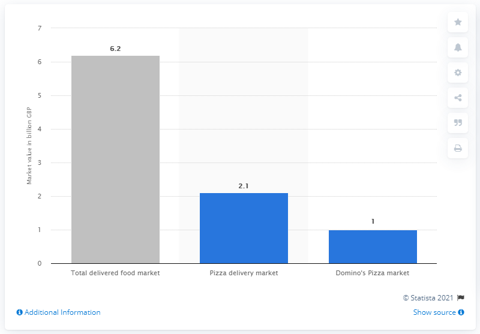

Q : What was the value of the pizza delivery market in the UK at the end of 2017?
정답: 6.2 | 학습 모델 예측: 2.1
----------------------------------------------------------------------


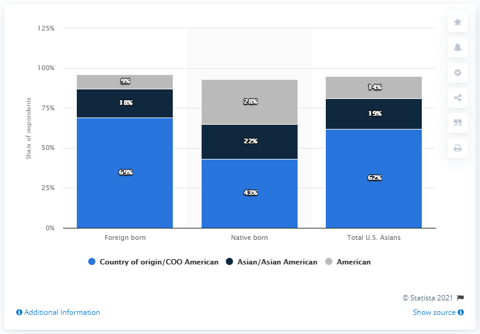

Q : What is the smallest value represented
정답: 9 | 학습 모델 예측: 1
----------------------------------------------------------------------


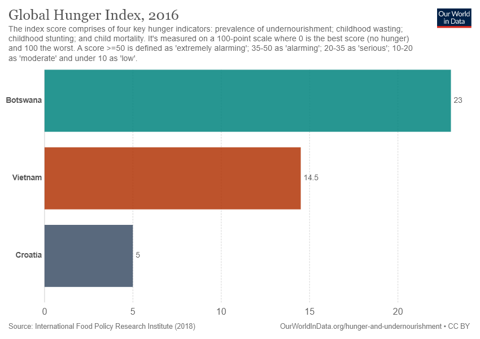

Q : Is Croatia global hunger index extremely alarminhg?
정답: No | 학습 모델 예측: No
----------------------------------------------------------------------


In [9]:
# ── 학습 직후 바로 추론 확인 ─────────────────────────────────────────────
# 같은 세션에서 "학습에 쓰던 model"을 그대로 재사용하므로,
# 학습용 설정(캐시 off / 체크포인팅 on)을 추론용으로 되돌린다.
from IPython.display import display

model.config.use_cache = True                  # 생성 속도를 위해 KV 캐시 활성화
if hasattr(model.config, 'text_config'):
    model.config.text_config.use_cache = True  # Qwen3-VL의 하위 text_config도 동일하게 설정
model.gradient_checkpointing_disable()         # 체크포인팅 비활성화(생성과 캐시 사용 시 비권장)
model.eval()                                   # 추론 모드(드롭아웃 비활성화)

# 학습 때 사용한 전처리 함수(to_messages / shrink / process_vision_info)를 그대로 재사용
# → 학습/추론 포맷 불일치로 인한 성능 저하를 줄임
@torch.no_grad()
def predict(model, image, question, max_new_tokens=32):
    msgs = to_messages(shrink(image), question, None)  # 정답 없는 추론용 메시지
    text = processor.apply_chat_template(
        msgs, tokenize=False, add_generation_prompt=True
    )  # assistant 답변 시작 프롬프트까지 생성
    img_inputs, _ = process_vision_info(msgs)          # 멀티모달 입력용 이미지 정보 변환
    inputs = processor(
        text=[text], images=img_inputs, return_tensors='pt'
    ).to(model.device)                                 # 모델 디바이스(GPU/CPU)로 이동

    out = model.generate(
        **inputs, max_new_tokens=max_new_tokens, do_sample=False
    )  # greedy 생성(재현성 높음)

    # 프롬프트 길이 이후(= 새로 생성된 답변 부분)만 디코딩
    return processor.decode(
        out[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()

# val 300 샘플(저장본 우선) 중 3개를 즉석 점검
_vp = f'{DATA_DIR}/chartqa_val_300'
_val = (
    load_from_disk(_vp)
    if os.path.isdir(_vp)
    else load_dataset('HuggingFaceM4/ChartQA', split='val').shuffle(seed=42).select(range(300))
)

for ex in _val.select(range(3)):
    pred = predict(model, ex['image'], ex['query'])
    _thumb = ex['image'].copy()
    _thumb.thumbnail((480, 480))               # 노트북 출력용 축소(원본 이미지 불변)
    display(_thumb)                            # 차트 이미지 표시
    print('Q :', ex['query'])
    print('정답:', ex['label'][0], '| 학습 모델 예측:', pred)
    print('-' * 70)

# 정리: 이후 학습 셀과의 일관성을 위해 캐시를 다시 끔
model.config.use_cache = False
if hasattr(model.config, 'text_config'):
    model.config.text_config.use_cache = False

### 🔍 결과 해석 — 학습 직후 추론 (형식 vs 정확도)
- **형식은 학습됐습니다**: 예측이 `'2.1'`·`'1'`·`'No'` 처럼 **짧은 한 토막**으로 나옵니다. 2교시 베이스라인의 장황한 문단이 사라졌고, **종료 토큰까지 배워 제때 멈춥니다**(3교시 `<|im_end|>` 학습 효과).
- **정확도는 아직**: 예시 3개 중 `Croatia ... → No`만 맞고, 숫자 읽기(`6.2`를 `2.1`로) 둘은 틀렸습니다. **3,000샘플·375스텝·1 epoch**의 짧은 학습이라 *형식은 빠르게, 정밀한 수치 판독은 느리게* 좋아집니다.
- 즉 이 셀은 "**짧게·멈추기가 됐는지**"를 즉석 확인하는 용도이고, **정량 정확도(Relaxed Accuracy)는 5교시**에서 측정합니다. 더 올리려면 데이터·epoch·rank(r)를 늘리면 됩니다.

## 6. LoRA 어댑터 저장 (→ 5교시로 전달)

학습된 것은 **LoRA 어댑터(수십 MB)** 뿐입니다. 이를 저장해 5교시(평가·병합)에서 불러옵니다. 새 런타임 대비 **Google Drive**에 저장하면 안전합니다.

In [10]:
# ── LoRA 어댑터 저장 셀 ─────────────────────────────────────
# 이 셀의 목적:
# 1) 학습된 LoRA 어댑터를 디스크에 저장하고
# 2) 같은 경로에 processor(토크나이저/이미지 전처리 설정)도 함께 저장해
# 3) 다음 교시(평가/병합)에서 그대로 재사용할 수 있게 만드는 것

# 저장 경로 설정
# - VLM_DIR: 공통 헤더 셀에서 정의된 작업 루트(Drive 경로)
# - lora_adapter: 어댑터 저장 전용 폴더명
SAVE_DIR = f'{VLM_DIR}/lora_adapter'

# 폴더가 없으면 생성, 이미 있으면 에러 없이 통과
os.makedirs(SAVE_DIR, exist_ok=True)

# PEFT 어댑터 가중치/설정 저장
# - base 전체 모델이 아니라 "학습된 LoRA 부분"만 저장됨
model.save_pretrained(SAVE_DIR)

# processor 저장
# - 추론/재학습 시 동일한 토크나이저/멀티모달 전처리를 재현하기 위해 함께 저장
processor.save_pretrained(SAVE_DIR)

# 저장 확인 출력
print('어댑터 저장 위치:', SAVE_DIR)
print('내용:', os.listdir(SAVE_DIR))

어댑터 저장 위치: /content/drive/MyDrive/VLM_FT_2/lora_adapter
내용: ['README.md', 'adapter_model.safetensors', 'adapter_config.json', 'chat_template.jinja', 'tokenizer_config.json', 'tokenizer.json', 'processor_config.json']


## 7. OOM 대처 + 정리 + 다음 교시 예고

**OOM(Out Of Memory)이 나면** 위에서부터 차례로:
1. `per_device_train_batch_size=1`, `gradient_accumulation_steps=8`
2. `MAX_PIXELS`를 `128*28*28`로 낮춤(이미지 토큰↓)
3. `r=8`로 LoRA 랭크 축소
4. 런타임 재시작 후 다른 셀 없이 학습만

**이번 교시 산출물**: LoRA 어댑터(`SAVE_DIR`), 학습곡선, 메모리 비교표.

### 다음 교시 — Day1-5 · 평가·병합·내보내기
**Relaxed Accuracy**를 구현해 학습 전/후 val 점수를 비교하고, 어댑터를 base에 **병합(`merge_and_unload`)** 한 뒤 **HF Hub(비공개)에 push**해 Day2로 넘깁니다.

> ✅ **체크포인트**: ① 무엇이 동결/학습되는지 설명 가능 ② 학습 대상 비전 파라미터가 0임을 확인 ③ loss가 감소했고 어댑터를 저장했다.